<a href="https://colab.research.google.com/github/flipiwolker-alt/cv-video-analytics/blob/main/pz_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ПЗ 1 — Обработка изображений с OpenCV

In [ ]:
!pip install opencv-python-headless easyocr pandas matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 9.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
print(f'Загружен файл: {file_path}')

Saving photo_2026-05-07_05-38-18.jpg to photo_2026-05-07_05-38-18.jpg
Загружен файл: photo_2026-05-07_05-38-18.jpg


In [ ]:
import cv2
import numpy as np
import easyocr
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display

reader = easyocr.Reader(['ru', 'en'], gpu=True)

img = cv2.imread(file_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blurred = cv2.GaussianBlur(gray, (5, 5), 0)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = cv2.magnitude(sobelx, sobely)

_, mask = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY_INV)

R, G, B = cv2.split(img_rgb)

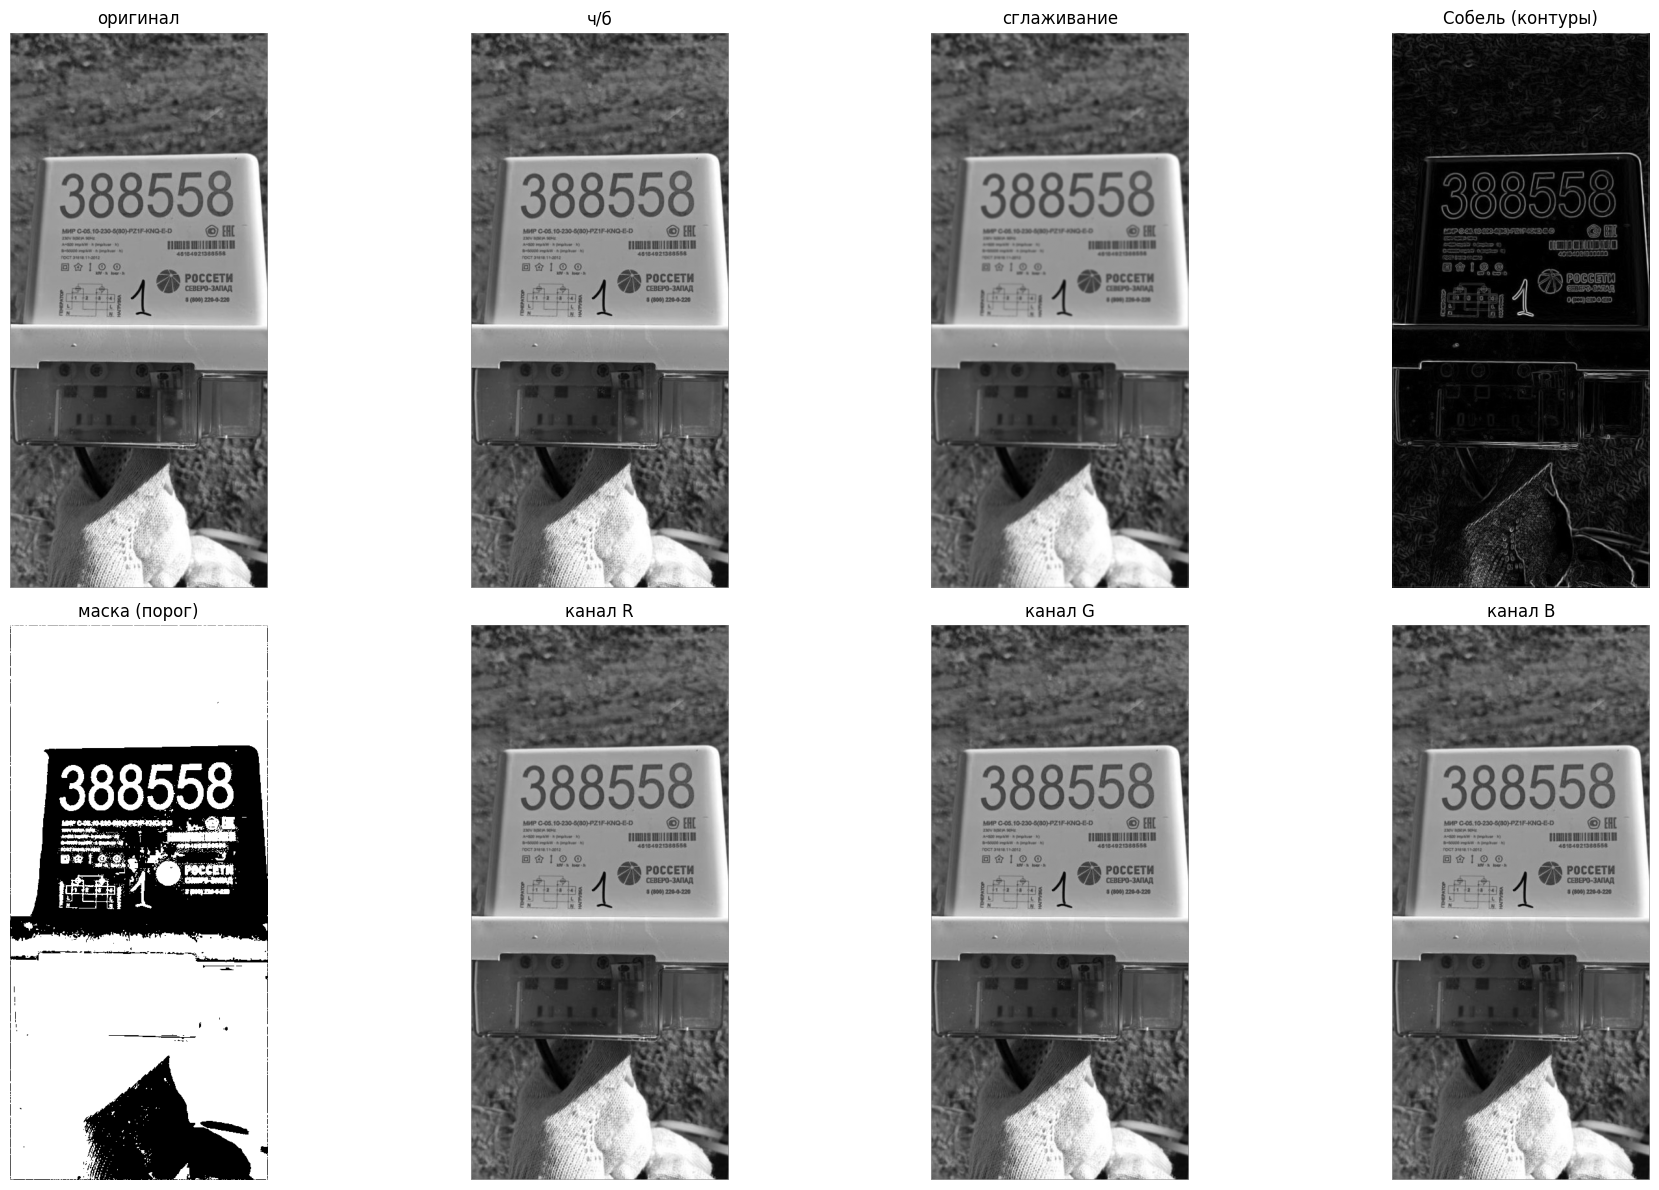

In [ ]:
plt.figure(figsize=(20, 12))
display_list = [
    (img_rgb,        'оригинал'),
    (gray,           'ч/б'),
    (blurred,        'сглаживание'),
    (sobel_combined, 'Собель (контуры)'),
    (mask,           'маска (порог)'),
    (R,              'канал R'),
    (G,              'канал G'),
    (B,              'канал B'),
]
for i, (image, title) in enumerate(display_list):
    plt.subplot(2, 4, i + 1)
    cmap = 'gray' if len(image.shape) == 2 else None
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# распознавание числового текста
results = reader.readtext(gray)
final_data = []

for (bbox, text, prob) in results:
    clean_text = ''.join(filter(str.isdigit, text))
    if len(clean_text) >= 5:
        final_data.append({
            'изображение': file_path.split('/')[-1],
            'результат': clean_text,
            'уверенность': round(prob, 3),
        })
        break

if final_data:
    display(pd.DataFrame(final_data))
else:
    print('Числовой текст (5+ цифр) не найден')

,изображение,результат,уверенность
0,photo_2026-05-07_05-38-18.jpg,388558,0.986
